# Step 1: Import Libraries & Load Data

In [1]:
# Import lib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(style="whitegrid")
%matplotlib inline

In [3]:
# Load datasets

df_country = pd.read_csv("country.csv")
df_university = pd.read_csv("university.csv")
df_university_year = pd.read_csv("university_year.csv")
df_ranking_criteria = pd.read_csv("ranking_criteria.csv")
df_ranking_system = pd.read_csv("ranking_system.csv")
df_university_ranking_year = pd.read_csv("university_ranking_year.csv")


# Step 2: Data Cleaning & Merging

In [4]:
# Merge university with country

df_merged = pd.merge(df_university, df_country, left_on='country_id', right_on='id', suffixes=('_uni', '_country'))
df_merged.drop(columns=['id_country'], inplace=True)


In [5]:
# Merge with yearly university data

df_year = pd.merge(df_merged, df_university_year, left_on='id_uni', right_on='university_id')

In [6]:
# Merge university_ranking_year with ranking_criteria using correct keys

df_ranking = pd.merge(
    df_university_ranking_year,
    df_ranking_criteria,
    left_on='ranking_criteria_id',
    right_on='id'
)


In [7]:
# Now merge with ranking_system 

df_ranking = pd.merge(
    df_ranking,
    df_ranking_system,
    left_on='ranking_system_id',
    right_on='id',
    suffixes=('_criteria', '_system')
)

In [8]:
# Final combined dataset with university-year and ranking information

df_final = pd.merge(df_year, df_ranking, on=['university_id', 'year'])


# Step 4: Visualization

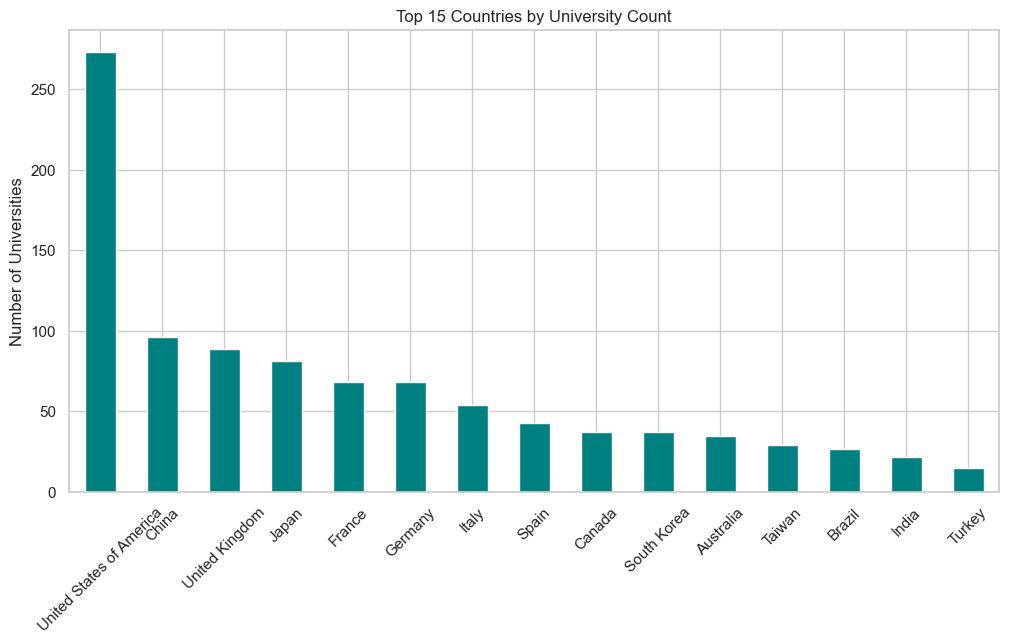

In [9]:
# Country-Wise University Count

country_counts = df_merged['country_name'].value_counts().head(15)

plt.figure(figsize=(12, 6))
country_counts.plot(kind='bar', color='teal')
plt.title("Top 15 Countries by University Count")
plt.ylabel("Number of Universities")
plt.xticks(rotation=45)
plt.show()


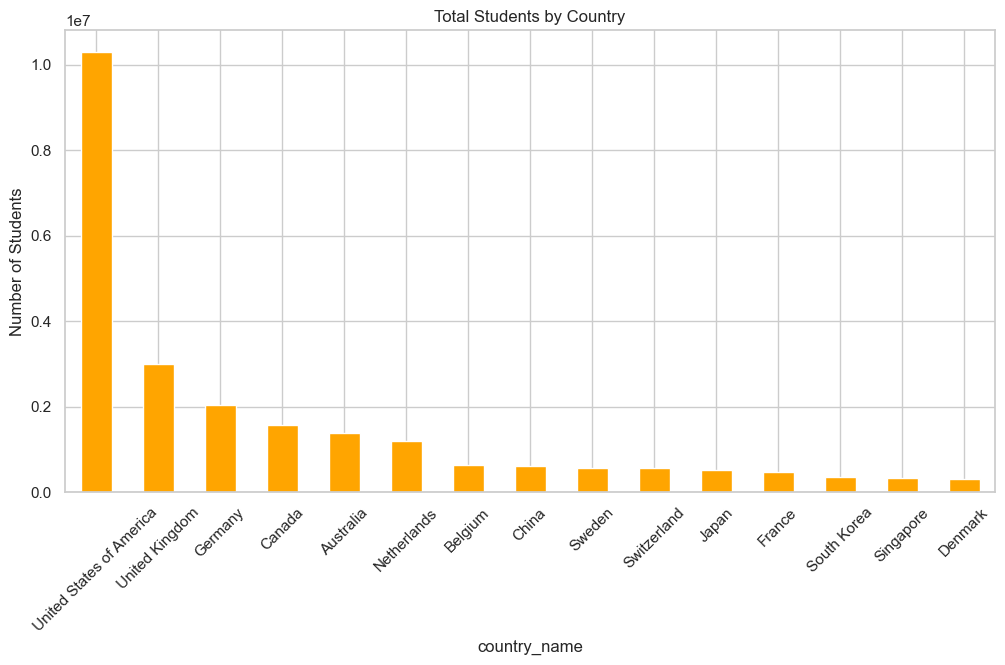

In [10]:
# Total Students by Country

total_students_country = df_year.groupby('country_name')['num_students'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
total_students_country.plot(kind='bar', color='orange')
plt.title("Total Students by Country")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()


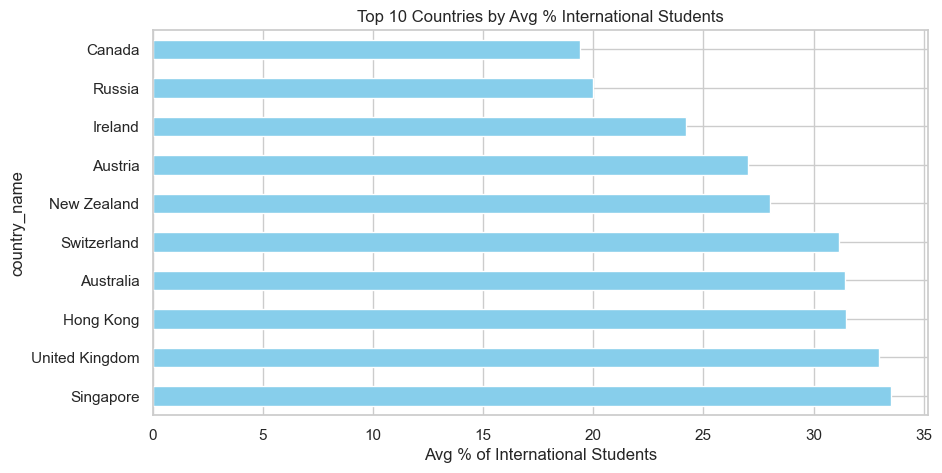

In [11]:
# International Students Percentage

intl_avg = df_year.groupby('country_name')['pct_international_students'].mean().dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
intl_avg.plot(kind='barh', color='skyblue')
plt.xlabel("Avg % of International Students")
plt.title("Top 10 Countries by Avg % International Students")
plt.show()


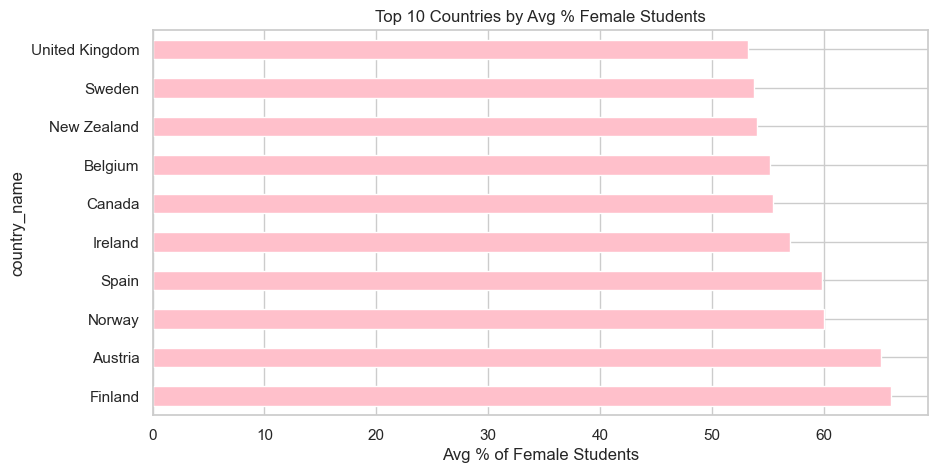

In [12]:
# Female Student Percentage

female_avg = df_year.groupby('country_name')['pct_female_students'].mean().dropna().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
female_avg.plot(kind='barh', color='pink')
plt.xlabel("Avg % of Female Students")
plt.title("Top 10 Countries by Avg % Female Students")
plt.show()


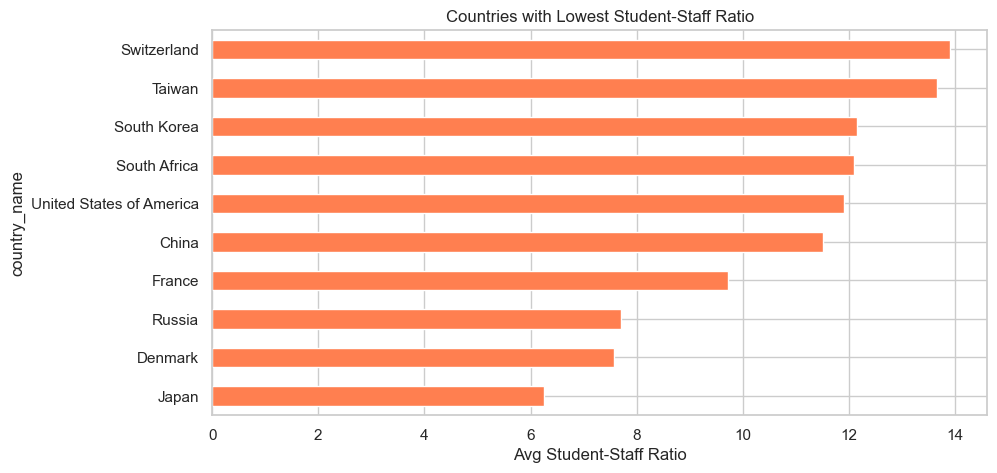

In [13]:
# Student-Staff Ratio by Country

ssr_avg = df_year.groupby('country_name')['student_staff_ratio'].mean().dropna().sort_values().head(10)

plt.figure(figsize=(10, 5))
ssr_avg.plot(kind='barh', color='coral')
plt.xlabel("Avg Student-Staff Ratio")
plt.title("Countries with Lowest Student-Staff Ratio")
plt.show()


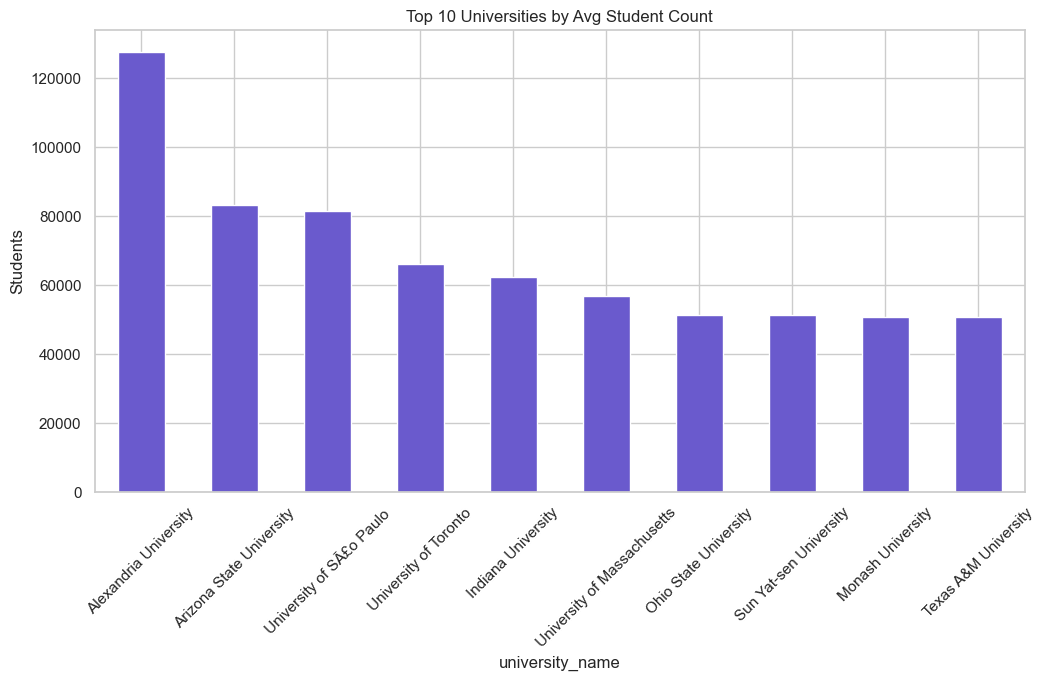

In [14]:
# University with Most Students

top_unis = df_year.groupby('university_name')['num_students'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_unis.plot(kind='bar', color='slateblue')
plt.title("Top 10 Universities by Avg Student Count")
plt.ylabel("Students")
plt.xticks(rotation=45)
plt.show()


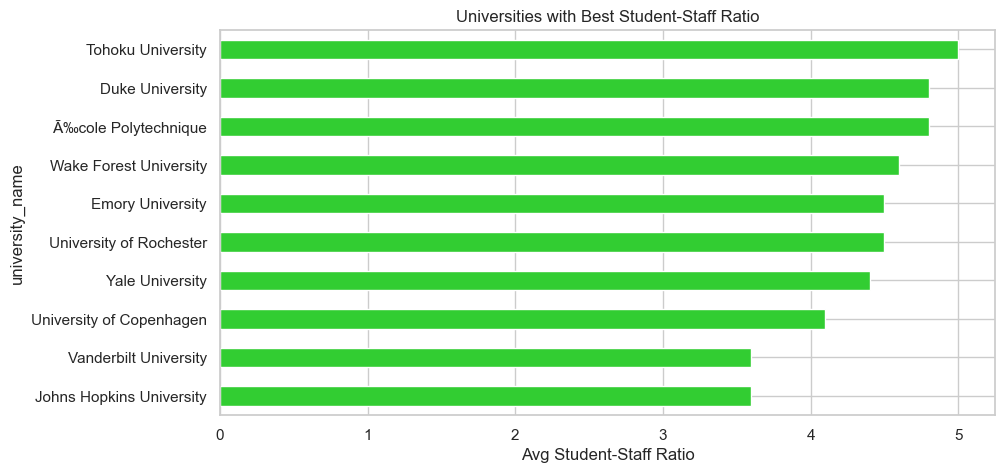

In [15]:
# Student-Staff Ratio by University

ssr_uni = df_year.groupby('university_name')['student_staff_ratio'].mean().dropna().sort_values().head(10)

plt.figure(figsize=(10, 5))
ssr_uni.plot(kind='barh', color='limegreen')
plt.xlabel("Avg Student-Staff Ratio")
plt.title("Universities with Best Student-Staff Ratio")
plt.show()


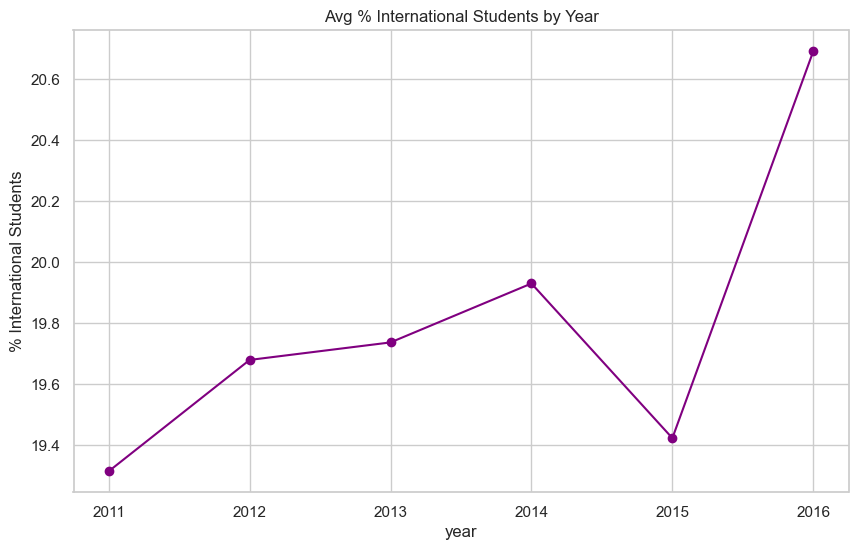

In [17]:
# Yearly Trends - International Students

intl_by_year = df_year.groupby('year')['pct_international_students'].mean()

plt.figure(figsize=(10, 6))
intl_by_year.plot(marker='o', color='purple')
plt.title("Avg % International Students by Year")
plt.ylabel("% International Students")
plt.grid(True)
plt.show()


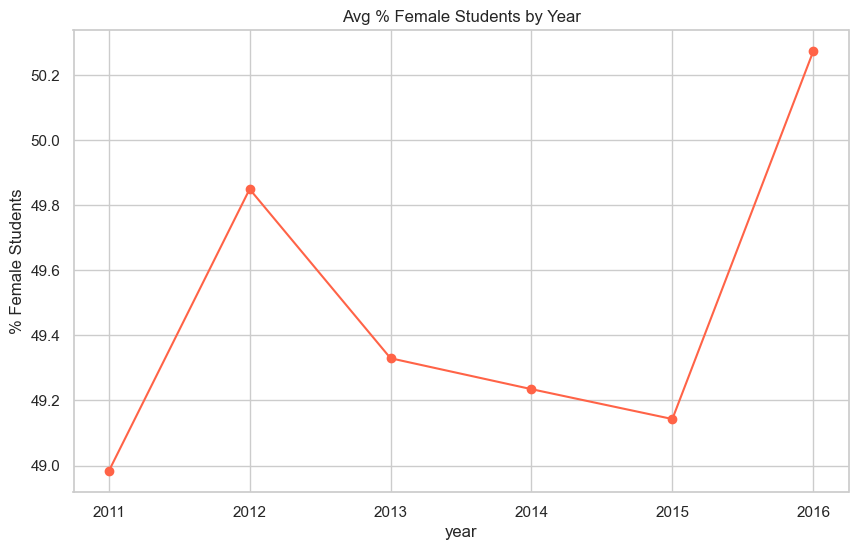

In [18]:
# Yearly Trends - Female Students

female_by_year = df_year.groupby('year')['pct_female_students'].mean()

plt.figure(figsize=(10, 6))
female_by_year.plot(marker='o', color='tomato')
plt.title("Avg % Female Students by Year")
plt.ylabel("% Female Students")
plt.grid(True)
plt.show()


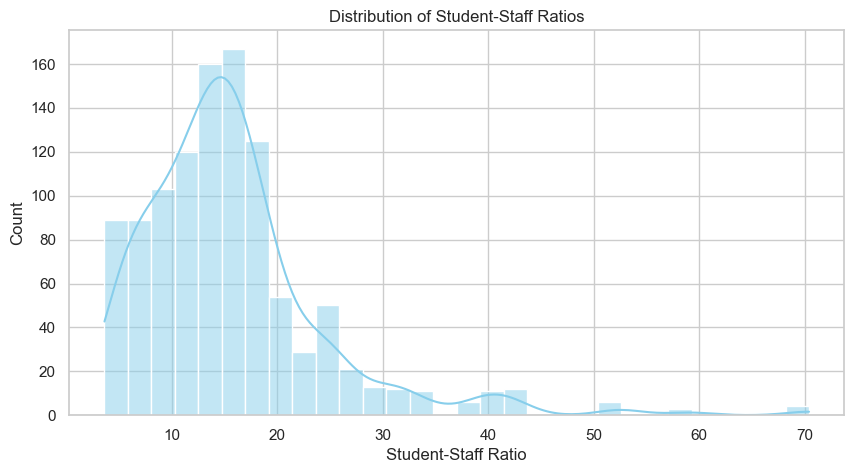

In [21]:
# Distribution of Student-Staff Ratios (Histogram)

plt.figure(figsize=(10, 5))
sns.histplot(df_year['student_staff_ratio'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Distribution of Student-Staff Ratios")
plt.xlabel("Student-Staff Ratio")
plt.show()


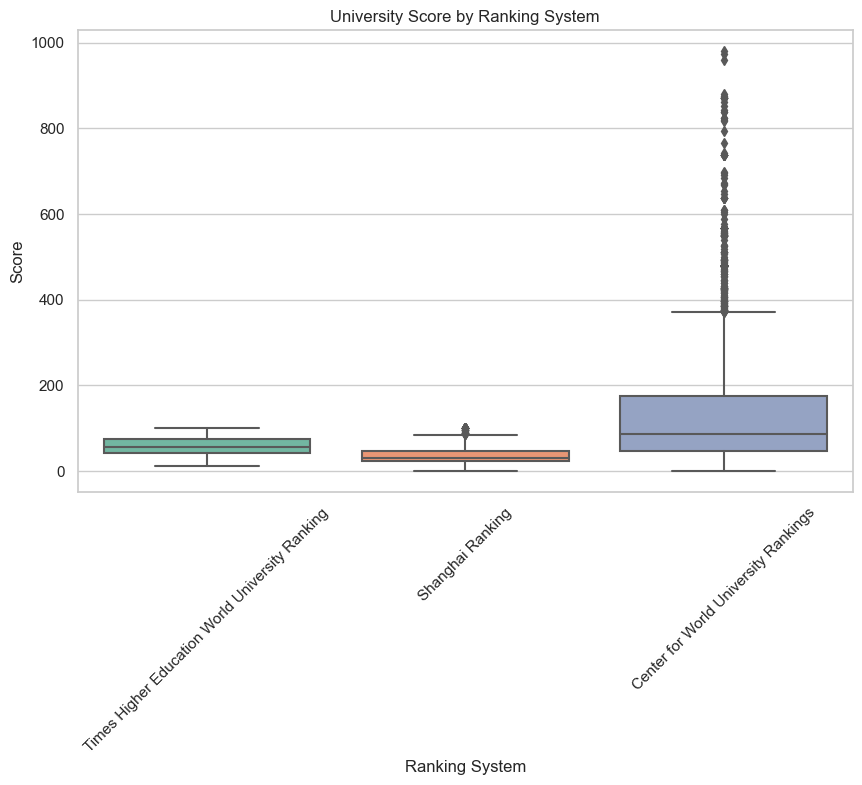

In [22]:
# Boxplot - Score by Ranking System

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_final, x='system_name', y='score', palette='Set2')
plt.title("University Score by Ranking System")
plt.xlabel("Ranking System")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


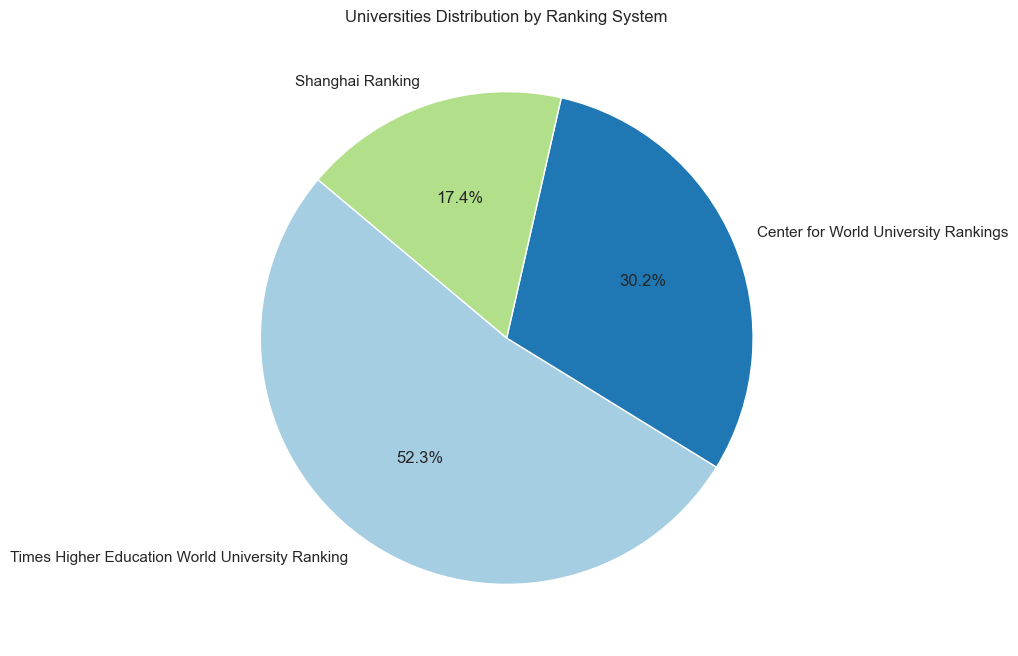

In [23]:
# Pie Chart - Ranking System Preference

ranking_counts = df_final['system_name'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(ranking_counts, labels=ranking_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title("Universities Distribution by Ranking System")
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_19740\3091300879.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df_year['num_students'].dropna(), shade=True, color='green')


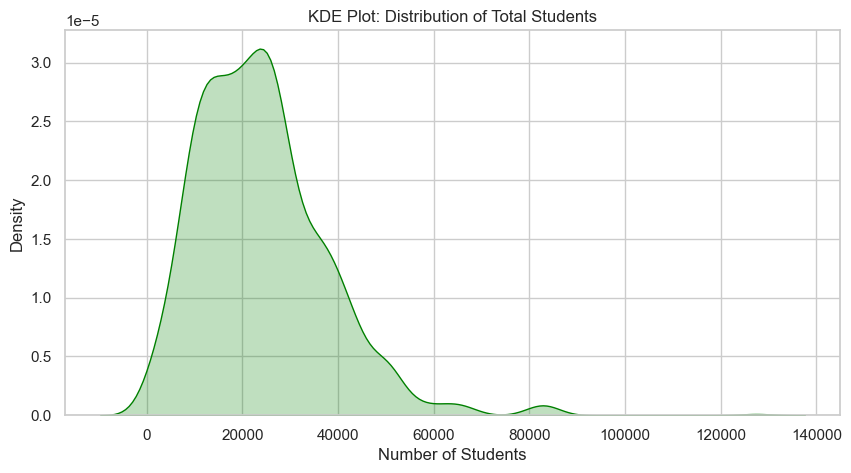

In [24]:
# KDE Plot - Total Students in All Universities

plt.figure(figsize=(10, 5))
sns.kdeplot(df_year['num_students'].dropna(), shade=True, color='green')
plt.title("KDE Plot: Distribution of Total Students")
plt.xlabel("Number of Students")
plt.show()


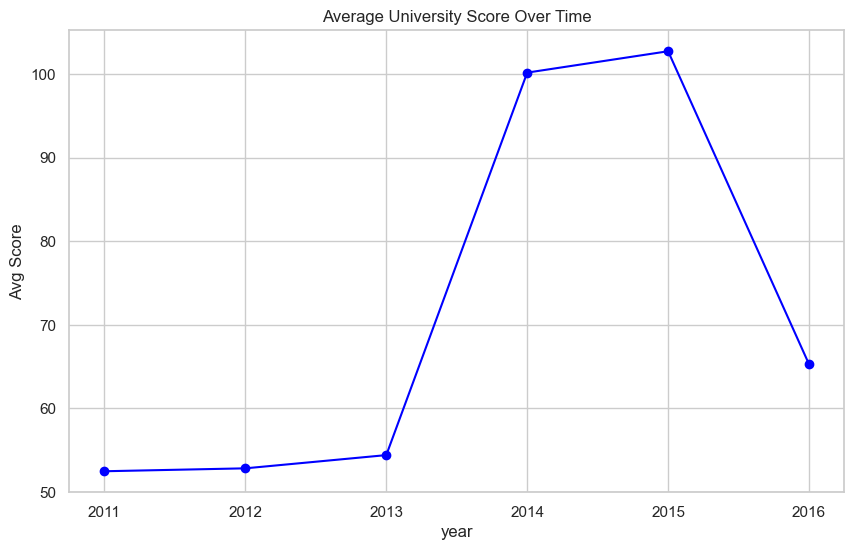

In [26]:
# Avg Score by Year 

avg_score_year = df_final.groupby('year')['score'].mean()

plt.figure(figsize=(10, 6))
avg_score_year.plot(marker='o', linestyle='-', color='blue')
plt.title("Average University Score Over Time")
plt.ylabel("Avg Score")
plt.grid(True)
plt.show()


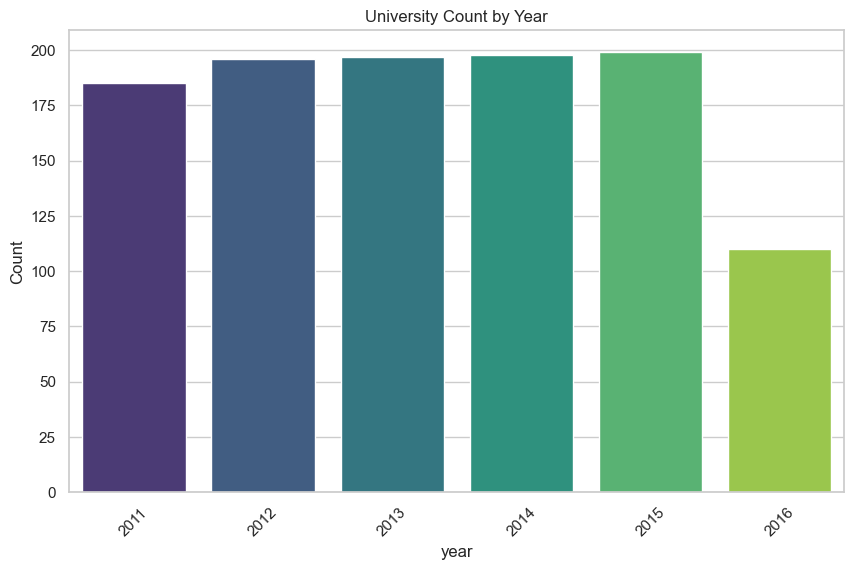

In [27]:
#  Number of Universities per Year

plt.figure(figsize=(10, 6))
sns.countplot(data=df_year, x='year', palette='viridis')
plt.title("University Count by Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


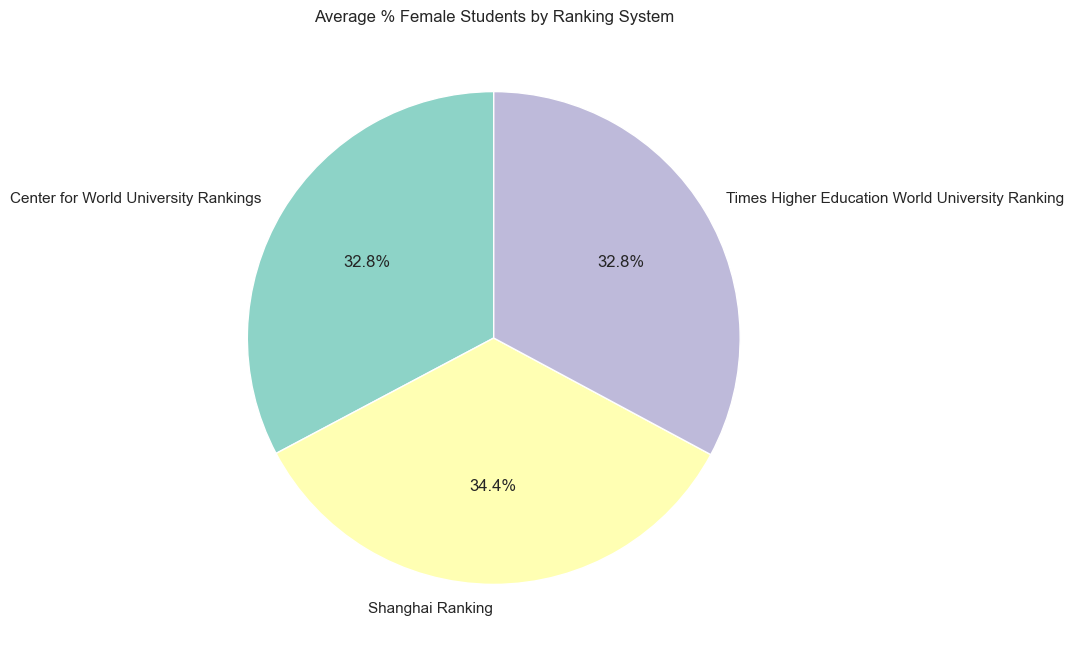

In [28]:
#  Pie Chart - Female Students by Ranking System

# Define the data again
female_by_system = df_final.groupby('system_name')['pct_female_students'].mean().dropna()

# Now plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    female_by_system,
    labels=female_by_system.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors
)
plt.title("Average % Female Students by Ranking System")
plt.show()


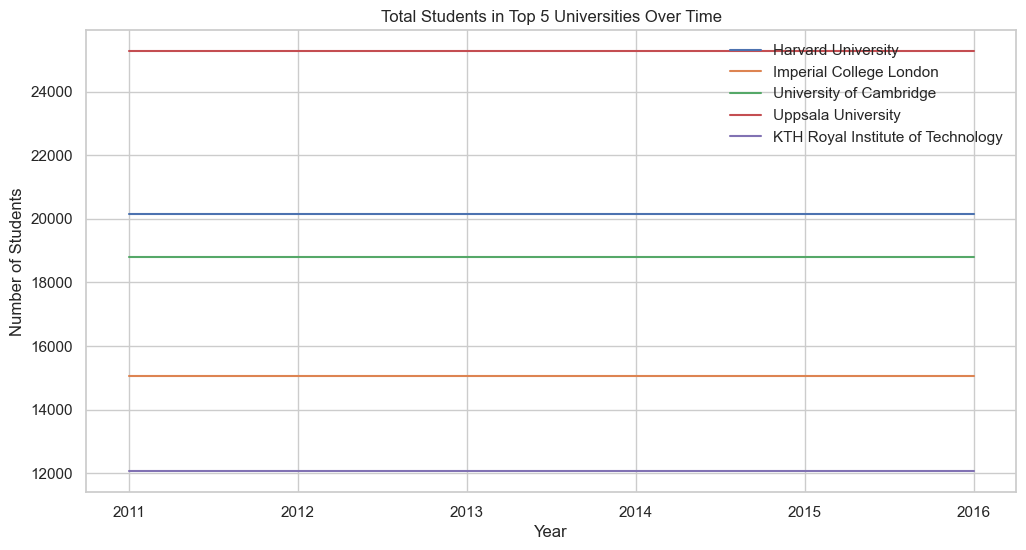

In [29]:
# Line Chart - Total Students by Top 5 Universities

top5_unis = df_year['university_name'].value_counts().head(5).index
df_top5 = df_year[df_year['university_name'].isin(top5_unis)]

plt.figure(figsize=(12, 6))
for uni in top5_unis:
    subset = df_top5[df_top5['university_name'] == uni]
    plt.plot(subset['year'], subset['num_students'], label=uni)
    
plt.legend()
plt.title("Total Students in Top 5 Universities Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()


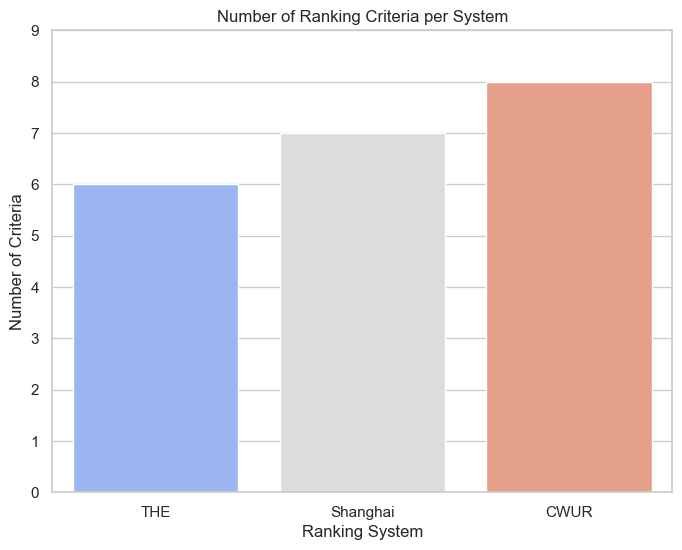

In [30]:
# Radar Chart - Criteria per Ranking System

# Step 1: Count criteria per ranking system
criteria_count = df_ranking_criteria['ranking_system_id'].value_counts().sort_index()

# Step 2: Map system IDs to names
system_labels = {1: 'THE', 2: 'Shanghai', 3: 'CWUR'}
criteria_count.index = criteria_count.index.map(system_labels)

# Step 3: Plot bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=criteria_count.index, y=criteria_count.values, palette='coolwarm')
plt.title("Number of Ranking Criteria per System")
plt.xlabel("Ranking System")
plt.ylabel("Number of Criteria")
plt.ylim(0, max(criteria_count.values) + 1)
plt.show()


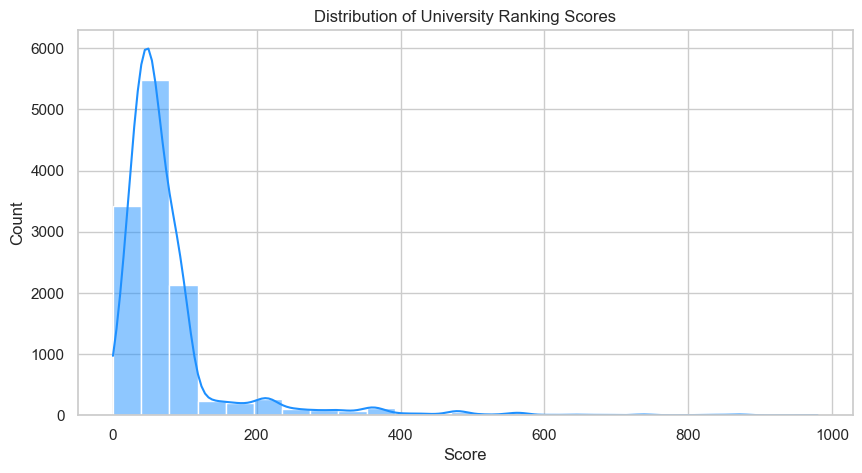

In [31]:
# Histogram - University Scores

plt.figure(figsize=(10, 5))
sns.histplot(df_final['score'], bins=25, kde=True, color='dodgerblue')
plt.title("Distribution of University Ranking Scores")
plt.xlabel("Score")
plt.show()


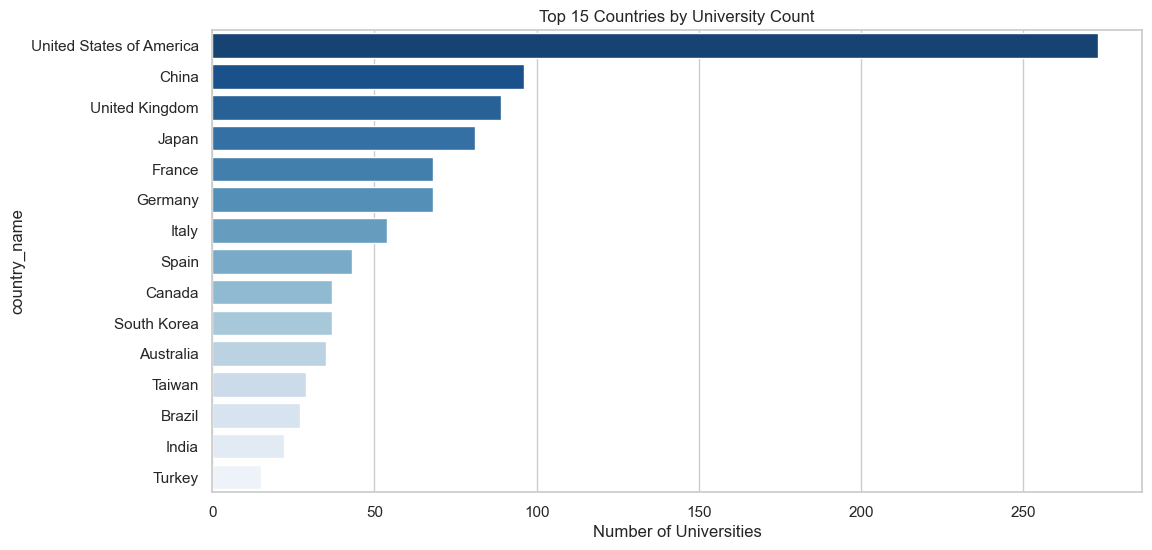

In [32]:
# Countplot - Top Countries with Most Ranked Universities

plt.figure(figsize=(12, 6))
sns.countplot(data=df_merged, y='country_name', order=df_merged['country_name'].value_counts().head(15).index, palette='Blues_r')
plt.title("Top 15 Countries by University Count")
plt.xlabel("Number of Universities")
plt.show()


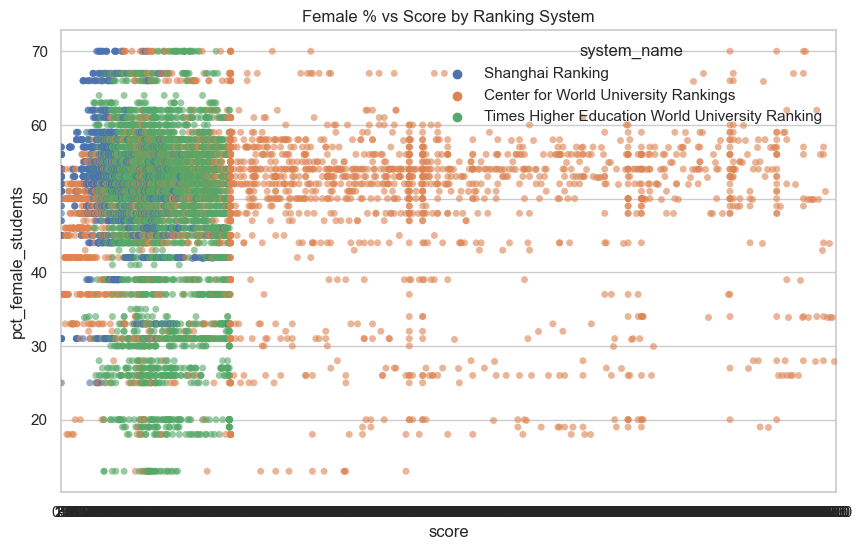

In [33]:
# Strip Plot - Female % vs Score

plt.figure(figsize=(10, 6))
sns.stripplot(data=df_final, x='score', y='pct_female_students', hue='system_name', dodge=True, alpha=0.6)
plt.title("Female % vs Score by Ranking System")
plt.show()


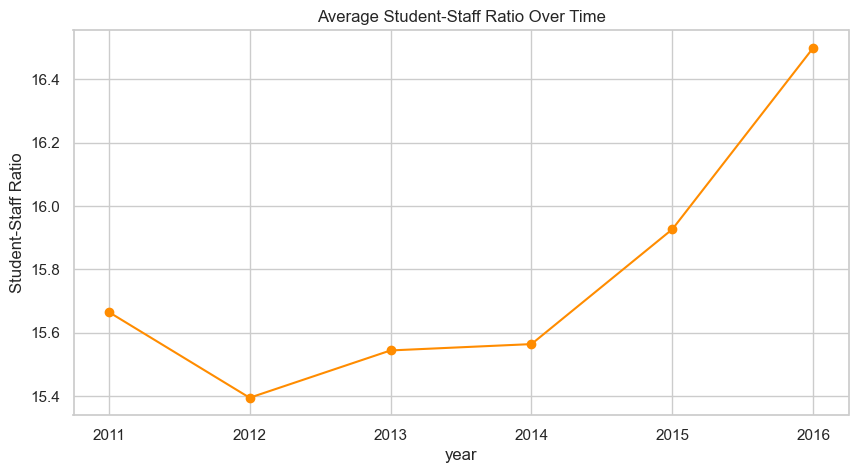

In [34]:
# Line Plot - Average Student-Staff Ratio Over Years

ssr_by_year = df_year.groupby('year')['student_staff_ratio'].mean()

plt.figure(figsize=(10, 5))
ssr_by_year.plot(marker='o', color='darkorange')
plt.title("Average Student-Staff Ratio Over Time")
plt.ylabel("Student-Staff Ratio")
plt.grid(True)
plt.show()


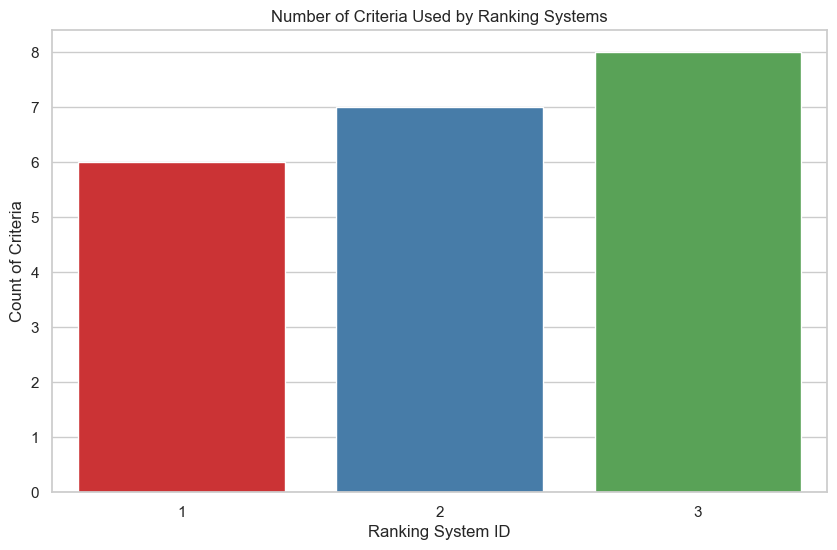

In [37]:
# Countplot - Ranking Criteria Count

plt.figure(figsize=(10, 6))
sns.countplot(data=df_ranking_criteria, x='ranking_system_id', palette='Set1')
plt.title("Number of Criteria Used by Ranking Systems")
plt.xlabel("Ranking System ID")
plt.ylabel("Count of Criteria")
plt.show()


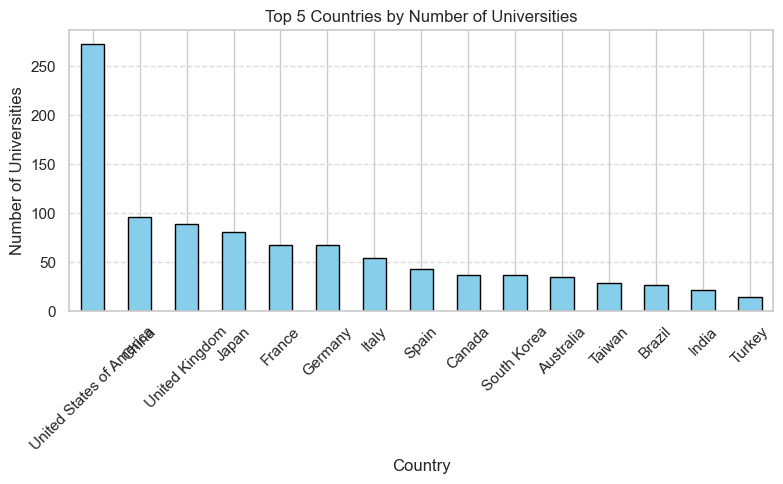

In [41]:
plt.figure(figsize=(8, 5))
country_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 5 Countries by Number of Universities')
plt.xlabel('Country')
plt.ylabel('Number of Universities')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()